# Hybrid Collaborative Filtering approach
Overview we have already done the item-based neighbhorhood collaborative filtering blended with a bbaseline bias model where we first fit the reguralized user and item biases using alternate update logic, create the user-item utility matrix, mean center the ratings in the matrix, measure item-item cosine similarity where similarity is users that rate two items similiarily, then we do bias adjusted top K prediction for each pair where we first find items most similar to target item in pair, get the residuals comparomh acyial rating - baseline prediction for neigboring item, predict based off forumla. We then also tuned the number of K neighbors. Now in thie iteration we will be adding new bias terms in the baseline that adds aspects of the movie metadata where we will learn the how much a uyser likes each genre of movie having a genre signal term made up of a user u's affinity for some genre g/
/ 
ex. \
`genre_signal(u, i) = (1 / |G_i|) · Σ_{g ∈ G_i} p_{u,g}`
- p_{u,g} : scalar for every (user, genre) pair
- G_i : set of genres movie i belongs to 
- Σ_{g ∈ G_i} p_{u,g} — sum the user's affinities, but only over the genres this movie has
- 1 / |G_i| — divide by the count of active genres

We also added a decade bias that is a scalar per decade bias which captures the rating trend for each era \
ex. \
940s ≈ +0.37, 2000s ≈ −0.34

\
Final Hybrid Bias Baseline Model Equation:\
`baseline(u,i) = μ + b_u + b_i + genre_signal(u,i) + b_decade[decade(i)]`



In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import time
from scipy.sparse import csr_matrix
from sklearn.metrics.pairwise import cosine_similarity
from evaluation_code import rmse

In [73]:
# first lets load in our datasets 
train= pd.read_csv('data/train.csv') # user-movie interaction file with ratings we can train on
test_pairs= pd.read_csv('data/test_pairs.csv') # user-movie pairs we need to get ratings for, can also thing of predicting rank
movies = pd.read_csv('data/movies.csv')  # movie metadata
users = pd.read_csv('data/users.csv')  # user metadata

# Temporal Validation Split

In [74]:
def make_val_split(df, frac=0.20):
    """
    Temporal validation 20% split, can adjust based on the frac parameter 
    Sort ratings from old to new and hold out tail frac percent 
    """
    train_rows = []  # collect individual user training part 
    val_rows   = [] # collect individual validation part

    for user_id, group in df.groupby("user_id"):  # one group for each user_id, dont use actual user_id just want observations with that user_id       
        group = group.sort_values("timestamp") # sort it
        n = len(group) # how many ratings total user has given 
        n_val = math.ceil(frac * n) # how many validation observations will be used, use ciel to round up, defensive programming
        train_rows.append(group.iloc[:n - n_val]) # older 80% used for training using slicing
        val_rows.append(group.iloc[n - n_val:])  # newer 20% used for training using slicing

    my_train = pd.concat(train_rows).reset_index(drop=True)  # add to one dataframe for train
    my_val   = pd.concat(val_rows).reset_index(drop=True)   # one dataframe for val
    return my_train, my_val

In [75]:
training_set, validation_set = make_val_split(train) 

In [76]:
val_truth = validation_set[["user_id", "item_id", "rating"]]

# Genre and Decade Feature Engineering
Each movie has a string encompassing the genres its a part of we will multi-hot encode these into 18 binary columns to account for movies and the nultiple genres they are a part of. We will also be bucketing different relase years into decades for eras of releases. We are also putting all previous to 1940 movies into one classic movie buckets as tehre not many movies before this time. 

In [77]:
# We have 18 genres from ReadME
ALL_GENRES = [
    "Action", "Adventure", "Animation", "Children's", "Comedy",
    "Crime", "Documentary", "Drama", "Fantasy", "Film-Noir",
    "Horror", "Musical", "Mystery", "Romance", "Sci-Fi",
    "Thriller", "War", "Western"
]

# iterate through the genres column and check if each row contains the some genre g and, regexFalse for hyphens
for g in ALL_GENRES:
    movies[g] = movies['genres'].str.contains(g, regex=False).astype(float)

# group by decade
movies['year_numeric'] = pd.to_numeric(movies['year'], errors='coerce') # turn into number format instead of datetime
movies['decade']   = (movies['year_numeric'].fillna(-1).astype(int) // 10 * 10).clip(lower=1940) # floor to decade, clip lower 1940 not a lot of movies previous to that year


genre_matrix = movies.set_index('item_id')[ALL_GENRES] # itemid lookup of the 18 dimension binary vector
decade_map   = movies.set_index('item_id')['decade'] # same idea for the ddcades 
genres_per_item = genre_matrix.sum(axis=1).clip(lower=1).rename('n_genres') # denominator for the averaging the genre affinities



In [78]:
genre_matrix

,Action,Adventure,Animation,Children's,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
item_id,,,,,,,,,,,,,,,,,,
1,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3948,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3949,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3950,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [79]:
decade_map

item_id
1       1990
2       1990
3       1990
4       1990
5       1990
        ... 
3948    2000
3949    2000
3950    2000
3951    2000
3952    2000
Name: decade, Length: 3883, dtype: int64

In [80]:
genres_per_item

item_id
1       3.0
2       3.0
3       2.0
4       2.0
5       1.0
       ... 
3948    1.0
3949    1.0
3950    1.0
3951    1.0
3952    2.0
Name: n_genres, Length: 3883, dtype: float64

## Reguralized Bias Estimation 
This is explained in the baseline notebook I will copy and paste this here for explanation. We will also.use reguralization to account for the case where a movie only has 1 rating of 5 stars this gives a high item bias that dominates. To account for this when calculating the item bias we will add  some lambda in the denominator b_i = sum(residuals) / count --> b_i = sum(residuals) / (count + λ_i) so in cases where rating count for item is large the lambda is negligble and is review count is low the lambda shrinks the bias and the predicted. rating falls around the global mean. \
We will also being using alternating updates for the reason beneath as mentioned.
To calculate user bias and item bias you need either or so to fix this we will start with initializing both biases at 0. Then iterate through each bias 20 times similar to weight update logic in SGD or BGD.


In [81]:
def build_genre_long(train_df, genre_matrix, genred_per_item): 
    """
    build a genre long dataframe with one row per rating genre pair, this is used to vectorize the p{u,g} updates no loops needed
    """
    # getting the genre vectors for each row for each item basically 
    n = len(train_df)

    item_ids = train_df['item_id'].values
    genre_flags = genre_matrix.reindex(item_ids, fill_value=0.0).values
    n_g = genred_per_item.reindex(item_ids).fillna(1.0).values

    #long form expansion where for each training rating we are adding one row per genre 
    # rating on 3 genre movie creates 3 rows each with a weight of 1/3
    chunks = []
    for genre_index, genre_name in enumerate(ALL_GENRES):
        mask = genre_flags[:, genre_index] == 1.0
        if mask.sum() == 0:
            continue
        chunks.append(pd.DataFrame({
        'row_index': np.where(mask)[0],
        'user_id': train_df['user_id'].values[mask],
        'genre':   genre_name,
        'weight':  1.0 / n_g[mask],
        }))
    genre_long = pd.concat(chunks, ignore_index=True)
    return genre_long

In [82]:

def fit_extended_bias(train_df, genre_matrix, decade_map, n_genres_per_item, global_mean, lambda_u=10.0, lambda_i=25.0, lambda_genre=10.0, lambda_decade=10.0, n_iter=20):
    """
    Extended bias model with the addition of the per-user genre affinity cand decade bias terms
    """
    df = train_df.copy() 
    df['decade']= df['item_id'].map(decade_map).fillna(1940).astype(int)
    df['n_genres']= df['item_id'].map(n_genres_per_item).fillna(1.0)

    genre_long = build_genre_long(train_df, genre_matrix, n_genres_per_item) # build genre long matrix

    # extract user ids, items, and decades
    users = train_df['user_id'].unique()
    items = train_df['item_id'].unique()
    decades = df['decade'].unique()

    # initialize to 0
    b_u= pd.Series(0.0, index=users)
    b_i= pd.Series(0.0, index=items)
    p_ug= pd.DataFrame(0.0, index=users, columns=ALL_GENRES)
    b_decade = pd.Series(0.0, index=decades)

    # get the column positions for p{ug} term once  to create single vectorized lookup
    # list comprehension :P
    genre_column_index = np.array([p_ug.columns.get_loc(g) for g in genre_long['genre']])

    def compute_genre_signal(df_local, pug_local, genre_long_local, genre_col_index_local):
        """
        For each genre-long row we want to lookup users affinity for the genre then multiply 1/|G_i|
        """
        user_row_index = pug_local.index.get_indexer(genre_long_local['user_id'])
        ug_vals = pug_local.to_numpy()[user_row_index, genre_col_index_local]
        weighted = ug_vals * genre_long_local['weight'].values
        contrib = pd.Series(weighted, index=genre_long_local['row_index']).groupby(level=0).sum()
        return contrib.reindex(range(len(df_local)), fill_value=0.0).values

    for iteration in range(n_iter):
        #current state of the genre and year signals, reused for the b_i and b_u updates below, updatesd every iter
        genre_signal = compute_genre_signal(df, p_ug, genre_long, genre_column_index)
        year_signal  = df['decade'].map(b_decade).fillna(0.0).values

        # broadcast onto every training row
        df['b_u_value'] = df['user_id'].map(b_u).fillna(0.0)
        df["b_i_value"] = df['item_id'].map(b_i).fillna(0.0)

        # update b_i calculate residual simialr to previous motebook
        df['res_i'] = df['rating'].values - global_mean - df['b_u_value'].values - genre_signal - year_signal
        st_i = df.groupby('item_id')['res_i'].agg(['sum', 'count'])
        b_i  = st_i['sum'] / (st_i['count'] + lambda_i)

        # update b_u using the fresh b_i
        df['b_i_value'] = df['item_id'].map(b_i).fillna(0.0)
        df['res_u'] = df['rating'].values - global_mean - df['b_i_value'].values - genre_signal - year_signal
        st_u = df.groupby('user_id')['res_u'].agg(['sum', 'count'])
        b_u  = st_u['sum'] / (st_u['count'] + lambda_u)

        # update p_ug, base_resid excludes the genre signal since thats what we are estimating
        df['b_u_value'] = df['user_id'].map(b_u).fillna(0.0)
        base_resid = df['rating'].values - global_mean - df['b_u_value'].values - df['b_i_value'].values - year_signal
        genre_long['base_resid'] = base_resid[genre_long['row_index'].values] #scatter residual to every active genre row
        genre_long['contrib']    = genre_long['base_resid'] * genre_long['weight']
        ug_stats= genre_long.groupby(['user_id', 'genre'])['contrib'].agg(['sum', 'count']) # one groupby for all user genre cells
        ug_new= (ug_stats['sum'] / (ug_stats['count'] + lambda_genre)).unstack(fill_value=0.0)
        p_ug= ug_new.reindex(index=users, columns=ALL_GENRES, fill_value=0.0)

        # update b_decade with fresh genre signal, base_resid excludes year signal since thats what we are estimating
        genre_signal_new = compute_genre_signal(df, p_ug, genre_long, genre_column_index)
        df['res_d'] = df['rating'].values - global_mean - df['b_u_value'].values - df['b_i_value'].values - genre_signal_new
        st_d = df.groupby('decade')['res_d'].agg(['sum', 'count'])
        b_decade = st_d['sum'] / (st_d['count'] + lambda_decade)

    return b_u, b_i, p_ug, b_decade


In [83]:
# fit extended bias with default lambdas, will be tuned later
global_mean = float(training_set["rating"].mean()) # global mean from training only, no leak

b_u, b_i, p_ug, b_decade = fit_extended_bias(
    training_set, genre_matrix, decade_map, genres_per_item, global_mean,
    lambda_u=10.0, lambda_i=25.0, lambda_genre=10.0, lambda_decade=10.0, n_iter=20
)

print(f"b_u range:[{b_u.min():.3f}, {b_u.max():.3f}]")
print(f"b_i range:[{b_i.min():.3f}, {b_i.max():.3f}]")
print(f"p_ug mean abs:{p_ug.abs().mean().mean():.4f}")
print(f"b_decade:\n{b_decade.sort_index().round(4).to_string()}")

b_u range:[-2.110, 1.153]
b_i range:[-1.420, 1.209]
p_ug mean abs:0.0394
b_decade:
decade
1940    0.3655
1950    0.2538
1960    0.2126
1970    0.0600
1980   -0.1443
1990   -0.2230
2000   -0.3378


# Compute the extended residual matrix

In [84]:
def compute_extended_residuals(train_df, genre_matrix, decade_map, n_genres_per_item,
                               global_mean, b_u, b_i, p_ug, b_decade):
    """
    Subtract full extended bias from each training rating to get cf only residuals
    """
    df = train_df.copy()
    # for coldstart fill with 0 not na
    df['b_u_value'] = df['user_id'].map(b_u).fillna(0.0)  
    df['b_i_value']= df['item_id'].map(b_i).fillna(0.0)
    df['decade']= df['item_id'].map(decade_map).fillna(1940).astype(int)
    df['year_signal'] = df['decade'].map(b_decade).fillna(0.0)

    # compute genre_signal using the same genre_long pattern in fit_extended_bias
    genre_long = build_genre_long(train_df, genre_matrix, n_genres_per_item)
    genre_column_index = np.array([p_ug.columns.get_loc(g) for g in genre_long['genre']])
    user_row_index= p_ug.index.get_indexer(genre_long['user_id'])
    ug_vals  = p_ug.to_numpy()[user_row_index, genre_column_index]
    weighted = ug_vals * genre_long['weight'].values
    
    genre_signal = pd.Series(weighted, index=genre_long['row_index']).groupby(level=0).sum().reindex(range(len(df)), fill_value=0.0).values

    residuals = df['rating'].values - global_mean - df['b_u_value'].values - df['b_i_value'].values - genre_signal - df['year_signal'].values
    return residuals

In [85]:
def build_residual_matrix(train_df, residuals):
    """    
    Build sparse user-item utility matrix from precomputed residuals
    We will return the csr matrix, user_to_id dictionary for lookup, item_to_id lookup, id_to_item lookup
    """
    user_ids = sorted(train_df['user_id'].unique()) 
    item_ids = sorted(train_df['item_id'].unique())

    user_to_id = {}
    for i, u in enumerate(user_ids):
        user_to_id[u] = i

    item_to_id = {}
    for i, m in enumerate(item_ids):
        item_to_id[m] = i

    id_to_item = {}
    for m, i in item_to_id.items():
        id_to_item[i] = m

    rows = train_df['user_id'].map(user_to_id).values
    cols = train_df['item_id'].map(item_to_id).values
    R = csr_matrix((residuals.astype(float), (rows, cols)), shape=(len(user_ids), len(item_ids)))
    
    return R, user_to_id, item_to_id, id_to_item

In [86]:
def mean_center(R):
    """
    Mean center each user row in csr without densifying
    """
    R_c = R.copy().astype(float) 
    row_sum = np.array(R_c.sum(axis=1)).flatten() # sum each row across the colmns, sum of all items for each user 
    row_count = np.array((R_c > 0).sum(axis=1)).flatten()  #count of ratings in a row, number of items user has rates
    user_mean = row_sum / np.maximum(row_count, 1) # get user mean rating
    for i in range(R_c.shape[0]):
        start = R_c.indptr[i] # row pointer array in csr format, for row i R_c.indptr[i] is the index in the data
        end = R_c.indptr[i + 1] # this is where it ends 
        if end > start:
            R_c.data[start:end] -= user_mean[i] # R_c.data[start:end] is the rating values for us
    return R_c, user_mean

In [87]:
# compute extended residuals then build sparse matrix then mean center per user
residuals = compute_extended_residuals( training_set, genre_matrix, decade_map, genres_per_item, global_mean, b_u, b_i, p_ug, b_decade)
R, user_to_id, item_to_id, id_to_item = build_residual_matrix(training_set, residuals)
R_centered, user_means_arr = mean_center(R)


In [88]:
# item-item cosine similarity for the extended residuals
item_sim = cosine_similarity(R_centered.T)
print(f" item_sim shape: {item_sim.shape}")

 item_sim shape: (3635, 3635)


In [89]:
def predict_hybrid_cf(pairs, R, item_sim, user_to_id, item_to_id, id_to_item, global_mean, b_u, b_i, p_ug, b_decade, genre_matrix, decade_map, n_genres_per_item, K=20):
    """
    Genre-personalized bias plus item cf hybrid prediction
    r_hat = clip(mu + b_u + b_i + genre_signal + b_decade + cf_signal, 1, 5)
    """
    predictions = []

    # convert to numpy and dictionaries for fast lookup .loc was way too slow
    p_ug_np = p_ug.to_numpy()
    userid_to_row_pug = {u: i for i, u in enumerate(p_ug.index)}
    genre_matrix_np = genre_matrix.to_numpy()
    itemid_to_row_genre= {m: i for i, m in enumerate(genre_matrix.index)}
    n_genres_per_item_vals = n_genres_per_item.to_dict()
    b_u_dict = b_u.to_dict()
    b_i_dict= b_i.to_dict()
    b_decade_dict= b_decade.to_dict()
    decade_dict= decade_map.to_dict()

    for row in pairs.itertuples(index=False): # itertuples fastest pandas row iteration
        user_id = row.user_id
        item_id = row.item_id

        # fallbacks for missing stuff
        b_u_val = b_u_dict.get(user_id, 0.0) 
        b_i_val= b_i_dict.get(item_id, 0.0)
        decade= int(decade_dict.get(item_id, 1940))
        year_signal = b_decade_dict.get(decade, 0.0)

        # genre signal
        genre_signal = 0.0
        if item_id in itemid_to_row_genre and user_id in userid_to_row_pug: # check cold start
            flags= genre_matrix_np[itemid_to_row_genre[item_id]] # look for item genre vector
            active = flags > 0 # convert to false trye
            if active.any(): # check for movie with no genres, skip and leave genre signal as 0
                n_g = n_genres_per_item_vals.get(item_id, 1.0)
                genre_signal  = float(p_ug_np[userid_to_row_pug[user_id]][active].sum() / n_g)

        baseline = global_mean + b_u_val + b_i_val + genre_signal + year_signal # extended bias prediction we are also using this as fallback

        # cold start checks for cf fall back to baseline
        if item_id not in item_to_id or user_id not in user_to_id:
            predictions.append(float(np.clip(baseline, 1.0, 5.0)))
            continue

        user_index = user_to_id[user_id]
        item_index = item_to_id[item_id]

        rated_col_indices      = R[user_index].indices # items the user rated
        rated_residuals = R[user_index].data    # already extended residuals, no recompute

        if len(rated_col_indices) == 0: # another fallback 
            predictions.append(float(np.clip(baseline, 1.0, 5.0)))
            continue

        similar= item_sim[item_index, rated_col_indices] # similarity of target to rated items
        top_k_indices = np.argsort(similar)[::-1][:K] # top K most similar indices
        top_similars = similar[top_k_indices] # top K most similar scores
        top_residuals  = rated_residuals[top_k_indices]

        pos_mask = top_similars > 0 # filter for positive similarities only
        top_similars= top_similars[pos_mask]
        top_residuals  = top_residuals[pos_mask]

        if len(top_similars) == 0: # if K neigbors has negative similarity fall back to bias model
            predictions.append(float(np.clip(baseline, 1.0, 5.0)))
            continue

        cf_signal = np.dot(top_similars, top_residuals) / np.sum(np.abs(top_similars)) # weighted residual avg
        predictions.append(float(np.clip(baseline + cf_signal, 1.0, 5.0)))  # get the predicted rating clip so its in right range

    output_df = pairs[['user_id', 'item_id']].copy()
    output_df['predicted_rating'] = predictions
    return output_df

# Tune K Neighbor Amount
We are tuning how many similar neighbor movies to include in the weighted average. This is a hyperparameter to tune

In [90]:
# tune K, only prediction time hyperparameter so no refit needed
K_values = [10, 20, 25, 30, 50]
k_results = []
# for loop to run through different K values
for K in K_values:
    print(f" K={K}...")
    
    # input into our predict rating method
    preds_k = predict_hybrid_cf(
        validation_set[['user_id', 'item_id']], R, item_sim,
        user_to_id, item_to_id, id_to_item,
        global_mean, b_u, b_i, p_ug, b_decade, genre_matrix, decade_map, genres_per_item, K=K
    )

    # put into the set rmse function
    score = rmse(val_truth, preds_k)
    print(f"RMSE={score:.4f}")
    k_results.append({'K': K, 'val_rmse': score})

k_df = pd.DataFrame(k_results)
best_K = int(k_df.loc[k_df['val_rmse'].idxmin(), 'K'])
print(f"\n Best K={best_K}, RMSE={k_df['val_rmse'].min():.4f}")

 K=10...


RMSE=0.8860
 K=20...
RMSE=0.8765
 K=25...
RMSE=0.8754
 K=30...
RMSE=0.8751
 K=50...
RMSE=0.8757

 Best K=30, RMSE=0.8751


/var/folders/sz/_mlq7slj15vg1f70zg680jwr0000gn/T/ipykernel_10677/3610482468.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


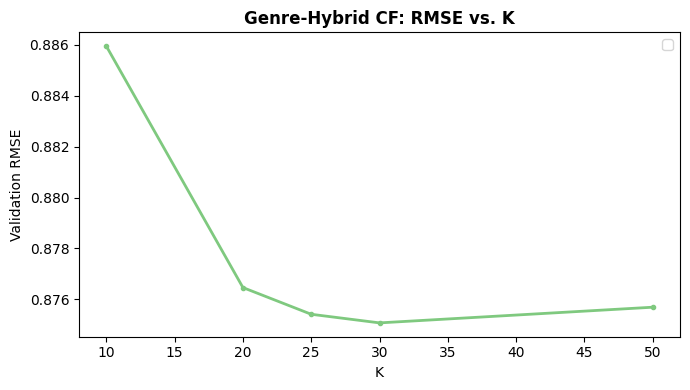

In [91]:
# plot K against rmse
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(k_df['K'], k_df['val_rmse'], marker='.', color=sns.color_palette('Accent')[0], linewidth=2)
ax.set_xlabel('K')
ax.set_ylabel('Validation RMSE')
ax.set_title('Genre-Hybrid CF: RMSE vs. K', fontweight='bold')
ax.legend()
plt.tight_layout()

# Tune Lambdas for reguraliztaion for genre and decade

In [92]:
# tune lambda_genre
lambda_genre_grid = [1, 5, 10, 25, 50]
lamda_genre_results = []

for lambda_genre in lambda_genre_grid:
    #run through whole pipeline store RMSE for each lambda
    print(f"lambda_genre={lambda_genre}...")
    b_u_lg, b_i_lg, pug_lg, b_d_lg = fit_extended_bias(
        training_set, genre_matrix, decade_map, genres_per_item, global_mean,
        lambda_u=10, lambda_i=25, lambda_genre=lambda_genre, lambda_decade=10, n_iter=20
    )

    res_t = compute_extended_residuals(
        training_set, genre_matrix, decade_map, genres_per_item,
        global_mean, b_u_lg, b_i_lg, pug_lg, b_d_lg
    )

    R_lg, user_to_index_lg, item_to_index_lg, column_to_item_lg = build_residual_matrix(training_set, res_t)
    Rc_lg, _ = mean_center(R_lg)
    similarity_lg   = cosine_similarity(Rc_lg.T)
    predictions_lg = predict_hybrid_cf(
        validation_set[['user_id', 'item_id']], R_lg, similarity_lg, user_to_index_lg, item_to_index_lg, column_to_item_lg,
        global_mean, b_u_lg, b_i_lg, pug_lg, b_d_lg, genre_matrix, decade_map, genres_per_item, K=best_K
    )
    score_t = rmse(val_truth, predictions_lg)
    print(f"RMSE={score_t:.4f}")
    lamda_genre_results.append({'lambda_genre': lambda_genre, 'val_rmse': score_t})

lg_df= pd.DataFrame(lamda_genre_results)
best_lambda_genre = int(lg_df.loc[lg_df['val_rmse'].idxmin(), 'lambda_genre'])
print(f"\n Best lambda_genre={best_lambda_genre}, RMSE={lg_df['val_rmse'].min():.4f}")

lambda_genre=1...
RMSE=0.8752
lambda_genre=5...
RMSE=0.8750
lambda_genre=10...
RMSE=0.8751
lambda_genre=25...
RMSE=0.8752
lambda_genre=50...
RMSE=0.8754

 Best lambda_genre=5, RMSE=0.8750


In [93]:
# tune lambda_decade with best lambda_genre fixed
lambda_decade_grid = [1, 5, 10, 25, 50]
ld_results = []

for lamda_decade in lambda_decade_grid:
    print(f" lambda_decade={lamda_decade}...")
    b_u_lg, b_i_lg, pug_lg, b_d_lg = fit_extended_bias(
        training_set, genre_matrix, decade_map, genres_per_item, global_mean,
        lambda_u=10, lambda_i=25, lambda_genre=best_lambda_genre, lambda_decade=lamda_decade, n_iter=20
    )
    res_t = compute_extended_residuals(
        training_set, genre_matrix, decade_map, genres_per_item,
        global_mean, b_u_lg, b_i_lg, pug_lg, b_d_lg
    )
    R_lg, user_to_index_lg, item_to_index_lg, column_to_item_lg = build_residual_matrix(training_set, res_t)
    Rc_lg, _ = mean_center(R_lg)
    similarity_lg   = cosine_similarity(Rc_lg.T)
    predictions_lg = predict_hybrid_cf(
        validation_set[['user_id', 'item_id']], R_lg, similarity_lg, user_to_index_lg, item_to_index_lg, column_to_item_lg,
        global_mean, b_u_lg, b_i_lg, pug_lg, b_d_lg, genre_matrix, decade_map, genres_per_item, K=best_K
    )
    score_t = rmse(val_truth, predictions_lg)
    print(f"RMSE={score_t:.4f}")
    ld_results.append({'lambda_decade': lamda_decade, 'val_rmse': score_t})

ld_df              = pd.DataFrame(ld_results)
best_lambda_decade = int(ld_df.loc[ld_df['val_rmse'].idxmin(), 'lambda_decade'])
print(f"\n Best lambda_decade={best_lambda_decade}, RMSE={ld_df['val_rmse'].min():.4f}")

 lambda_decade=1...
RMSE=0.8750
 lambda_decade=5...
RMSE=0.8750
 lambda_decade=10...
RMSE=0.8750
 lambda_decade=25...
RMSE=0.8750
 lambda_decade=50...
RMSE=0.8750

 Best lambda_decade=25, RMSE=0.8750


In [94]:
# retrain on full train.csv with best hyperparameters and save predictions
mu_full = float(train['rating'].mean())

b_u_f, b_i_f, p_ug_f, b_decade_f = fit_extended_bias(
    train, genre_matrix, decade_map, genres_per_item, mu_full,
    lambda_u=10, lambda_i=25,
    lambda_genre=best_lambda_genre, lambda_decade=best_lambda_decade, n_iter=20
)

res_f = compute_extended_residuals(
    train, genre_matrix, decade_map, genres_per_item,
    mu_full, b_u_f, b_i_f, p_ug_f, b_decade_f
)
R_f, u2i_f, i2i_f, i2item_f = build_residual_matrix(train, res_f)
Rc_f, _ = mean_center(R_f)
sim_f = cosine_similarity(Rc_f.T)

preds_final = predict_hybrid_cf(
    test_pairs, R_f, sim_f, u2i_f, i2i_f, i2item_f,
    mu_full, b_u_f, b_i_f, p_ug_f, b_decade_f,
    genre_matrix, decade_map, genres_per_item, K=best_K
)

preds_final.to_csv('predictions_genre_hybrid_cf.csv', index=False)
print(f"Saved ({len(preds_final):,} rows)")

Saved (202,451 rows)


In [95]:
# cold start analysis, items in val that were never seen in training
training_items = set(training_set['item_id'].unique())
cold_mask = ~validation_set['item_id'].isin(training_items)
cold_val = validation_set[cold_mask][['user_id', 'item_id', 'rating']]
warm_val = validation_set[~cold_mask][['user_id', 'item_id', 'rating']]
print(f"cold val ratings: {len(cold_val)}, warm val ratings: {len(warm_val)}")

# need val predictions for the hybrid, regenerate quickly
preds_hybrid_val = predict_hybrid_cf(
    validation_set[['user_id', 'item_id']], R, item_sim,
    user_to_id, item_to_id, id_to_item,
    global_mean, b_u, b_i, p_ug, b_decade,
    genre_matrix, decade_map, genres_per_item, K=best_K
)

# split predictions into cold and warm
cold_pred = preds_hybrid_val[preds_hybrid_val['item_id'].isin(cold_val['item_id'].unique())]
warm_pred = preds_hybrid_val[~preds_hybrid_val['item_id'].isin(cold_val['item_id'].unique())]

print(f"hybrid cold RMSE: {rmse(cold_val, cold_pred):.4f}")
print(f"hybrid warm RMSE: {rmse(warm_val, warm_pred):.4f}")

# also score the global mean baseline on the same cold subset for comparison
cold_mean_pred = cold_val[['user_id', 'item_id']].copy()
cold_mean_pred['predicted_rating'] = global_mean
print(f"global mean cold RMSE: {rmse(cold_val, cold_mean_pred):.4f}")


cold val ratings: 36, warm val ratings: 161999
hybrid cold RMSE: 1.2278
hybrid warm RMSE: 0.8750
global mean cold RMSE: 1.3459
